# AI Job Market Trends Analysis

# importing liberarys

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df=pd.read_csv(r"C:\Users\sunev\Downloads\ai_job_trends_dataset.csv")
print(df.head(5))

               Job Title       Industry  Job Status AI Impact Level  \
0     Investment analyst             IT  Increasing        Moderate   
1  Journalist, newspaper  Manufacturing  Increasing        Moderate   
2      Financial planner        Finance  Increasing             Low   
3        Legal secretary     Healthcare  Increasing            High   
4  Aeronautical engineer             IT  Increasing             Low   

   Median Salary (USD) Required Education  Experience Required (Years)  \
0             42109.76    Master’s Degree                            5   
1            132298.57    Master’s Degree                           15   
2            143279.19  Bachelor’s Degree                            4   
3             97576.13   Associate Degree                           15   
4             60956.63    Master’s Degree                           13   

   Job Openings (2024)  Projected Openings (2030)  Remote Work Ratio (%)  \
0                 1515                       6342   

## 🧹 DATA CLEANING

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job Title                    30000 non-null  object 
 1   Industry                     30000 non-null  object 
 2   Job Status                   30000 non-null  object 
 3   AI Impact Level              30000 non-null  object 
 4   Median Salary (USD)          30000 non-null  float64
 5   Required Education           30000 non-null  object 
 6   Experience Required (Years)  30000 non-null  int64  
 7   Job Openings (2024)          30000 non-null  int64  
 8   Projected Openings (2030)    30000 non-null  int64  
 9   Remote Work Ratio (%)        30000 non-null  float64
 10  Automation Risk (%)          30000 non-null  float64
 11  Location                     30000 non-null  object 
 12  Gender Diversity (%)         30000 non-null  float64
dtypes: float64(4), i

In [22]:
df.shape

(30000, 13)

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.isnull().sum()

Job Title                      0
Industry                       0
Job Status                     0
AI Impact Level                0
Median Salary (USD)            0
Required Education             0
Experience Required (Years)    0
Job Openings (2024)            0
Projected Openings (2030)      0
Remote Work Ratio (%)          0
Automation Risk (%)            0
Location                       0
Gender Diversity (%)           0
dtype: int64

In [25]:
df.describe()

,Median Salary (USD),Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Gender Diversity (%)
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,90119.965639,10.051433,5039.640833,5074.218100,49.836431,50.154229,49.979660
std,34412.013953,6.060678,2861.009654,2866.550722,28.966688,28.754889,17.274665
min,30001.860000,0.000000,100.000000,100.000000,0.000000,0.000000,20.000000
25%,60500.702500,5.000000,2570.000000,2586.750000,24.570000,25.400000,35.070000
50%,90274.115000,10.000000,5034.000000,5106.500000,49.570000,50.020000,49.885000
75%,119454.710000,15.000000,7527.000000,7573.000000,75.100000,75.030000,64.910000
max,149998.500000,20.000000,10000.000000,10000.000000,100.000000,99.990000,80.000000


In [26]:
for col in df.select_dtypes(include='object'):
    print(col)
    print(df[col].unique())

Job Title
['Investment analyst' 'Journalist, newspaper' 'Financial planner'
 'Legal secretary' 'Aeronautical engineer' 'Surveyor, insurance' 'Dentist'
 'Emergency planning/management officer' 'Visual merchandiser'
 'Housing manager/officer' 'Geologist, wellsite'
 'Runner, broadcasting/film/video' 'Press photographer'
 'Biochemist, clinical' 'Town planner' 'Engineer, civil (consulting)'
 'Audiological scientist'
 'Clinical scientist, histocompatibility and immunogenetics'
 'Music therapist' 'Advertising copywriter' 'Commercial horticulturist'
 'Secondary school teacher' 'Production assistant, radio'
 'Armed forces technical officer' 'Youth worker' 'Special effects artist'
 'Ceramics designer' 'Animal technologist' 'Firefighter'
 'Charity fundraiser' 'Jewellery designer' 'Ecologist'
 'Operations geologist' 'Patent attorney' 'Media buyer' 'Tour manager'
 'Higher education careers adviser' 'Fitness centre manager'
 'Immunologist' 'Contracting civil engineer' 'Surgeon'
 'Environmental consu

In [27]:
df.to_csv("ai job market cleaned.csv",index=False)

## 📈 EXPLORATORY DATA ANALYSIS (EDA)

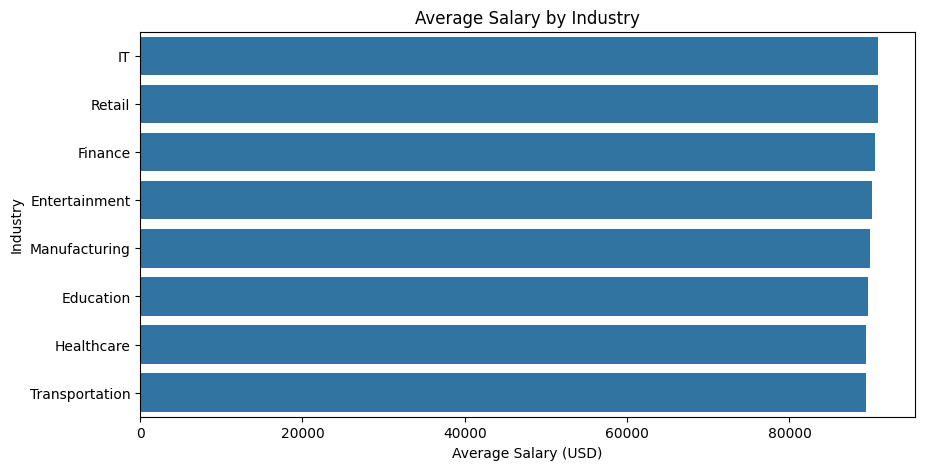

In [28]:
#1. Which industries offer the highest average salary?
industry_salary = df.groupby('Industry')['Median Salary (USD)'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=industry_salary.values,
            y=industry_salary.index)

plt.title('Average Salary by Industry')
plt.xlabel('Average Salary (USD)')
plt.ylabel('Industry')
plt.show()

**Objective:** Analyze and compare average salaries across industries.

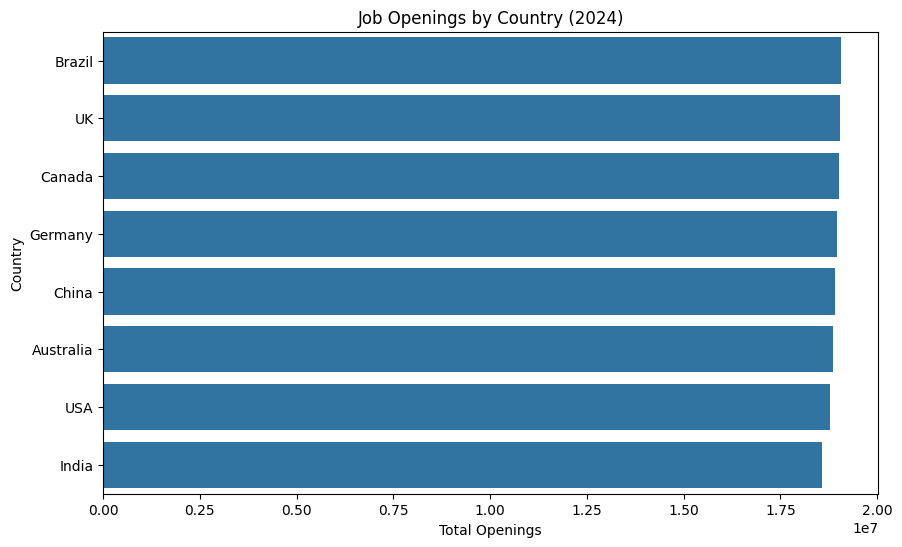

In [29]:
#2. Which countries have the highest job openings in 2024?
country_jobs = df.groupby('Location')['Job Openings (2024)'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=country_jobs.values,
            y=country_jobs.index)

plt.title('Job Openings by Country (2024)')
plt.xlabel('Total Openings')
plt.ylabel('Country')
plt.show()

**Objective:** Identify countries with the strongest demand for AI jobs.

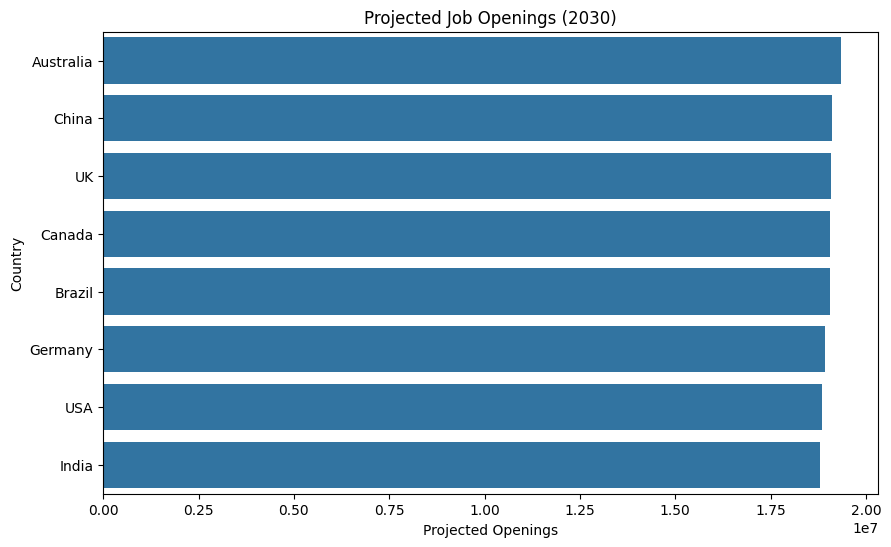

In [30]:
#3. Which countries are expected to have the most openings in 2030?
future_jobs = df.groupby('Location')['Projected Openings (2030)'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=future_jobs.values,
            y=future_jobs.index)

plt.title('Projected Job Openings (2030)')
plt.xlabel('Projected Openings')
plt.ylabel('Country')
plt.show()

**Objective:** Understand future workforce demand.


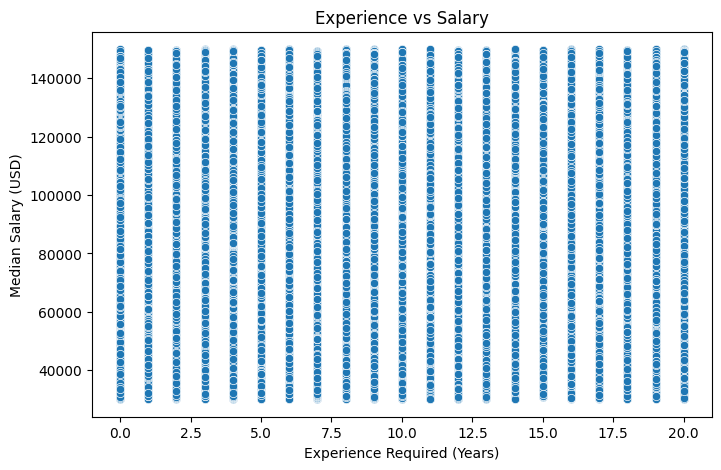

In [31]:
#5. Is there a relationship between experience and salary?
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Experience Required (Years)',
    y='Median Salary (USD)'
)

plt.title('Experience vs Salary')
plt.show()


**Objective:** Determine whether salary increases with experience.

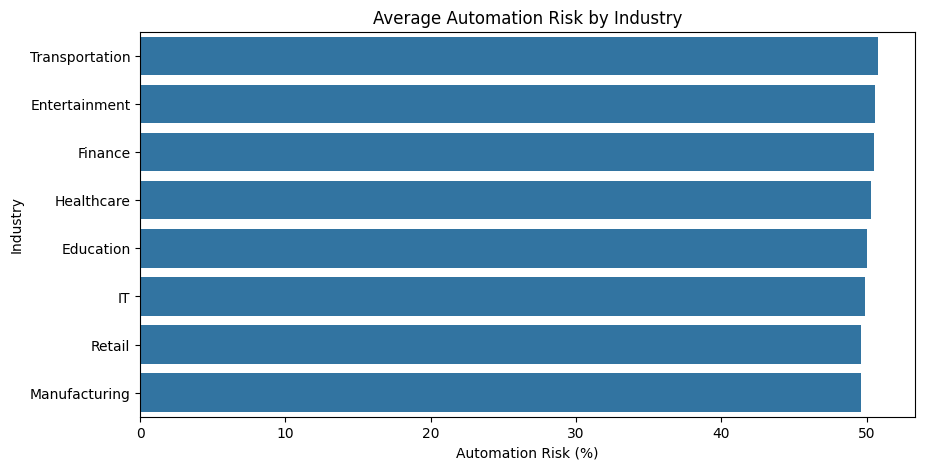

In [32]:
#6. Which industries face the highest automation risk?
automation = df.groupby('Industry')['Automation Risk (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=automation.values,
            y=automation.index)

plt.title('Average Automation Risk by Industry')
plt.xlabel('Automation Risk (%)')
plt.show()

**Objective:** Identify industries most vulnerable to AI automation.

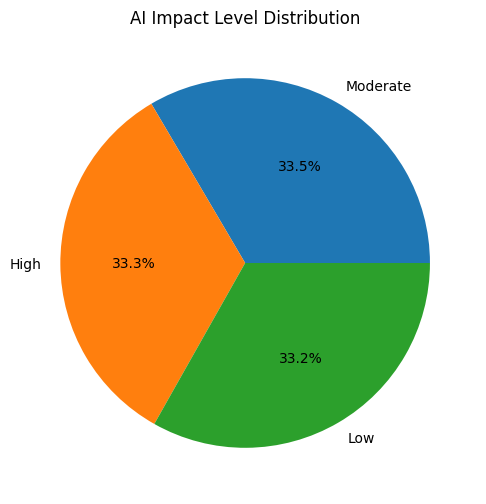

In [33]:
#7. What is the distribution of AI impact levels?
impact = df['AI Impact Level'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    impact.values,
    labels=impact.index,
    autopct='%1.1f%%'
)

plt.title('AI Impact Level Distribution')
plt.show()

**Objective:** Understand the overall distribution of AI impact.

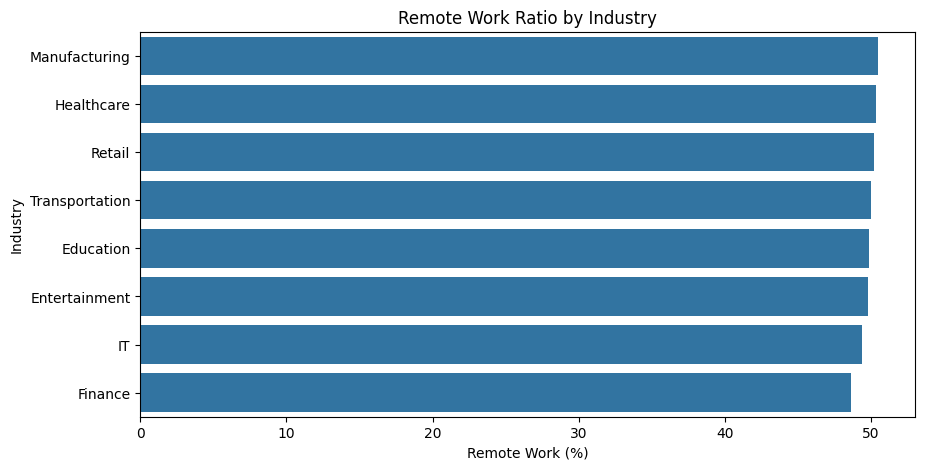

In [34]:
#8. Which industries have the highest remote work ratio?
remote = df.groupby('Industry')['Remote Work Ratio (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=remote.values,
            y=remote.index)

plt.title('Remote Work Ratio by Industry')
plt.xlabel('Remote Work (%)')
plt.show()

**Objective:** Explore remote work adoption across industries.

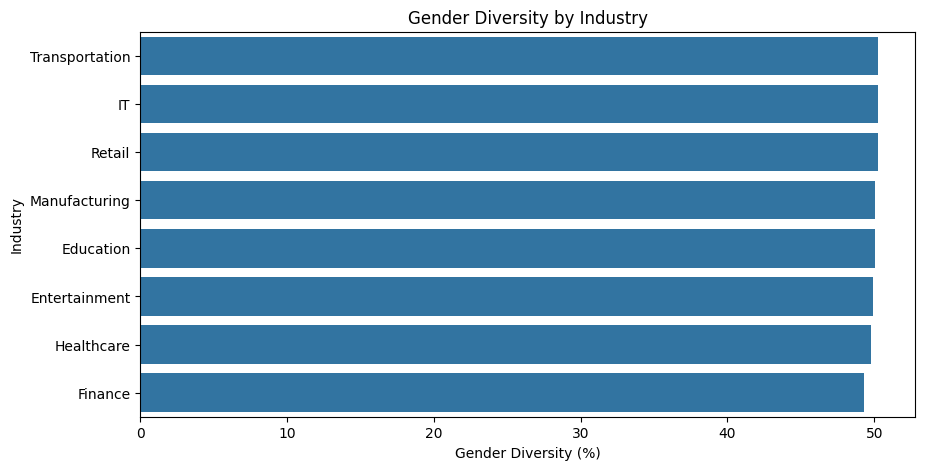

In [35]:
#9. Which industries have the highest gender diversity?
gender = df.groupby('Industry')['Gender Diversity (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=gender.values,
            y=gender.index)

plt.title('Gender Diversity by Industry')
plt.xlabel('Gender Diversity (%)')
plt.show()

**Objective:** Evaluate workforce inclusivity and diversity.

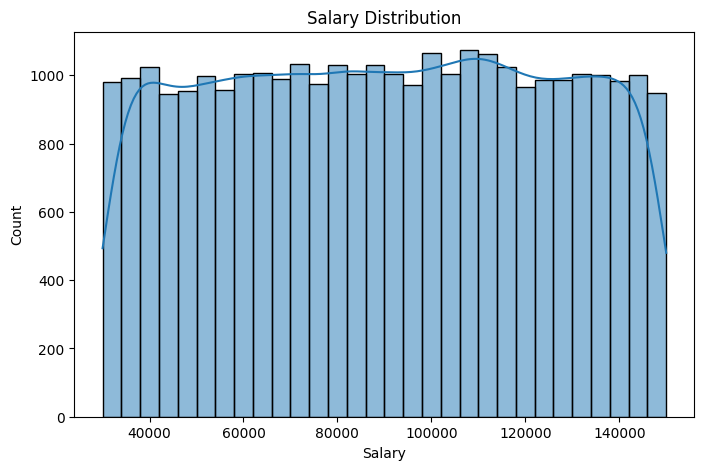

In [36]:
#10. What is the salary distribution across all jobs?
plt.figure(figsize=(8,5))

sns.histplot(
    df['Median Salary (USD)'],
    bins=30,
    kde=True
)

plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.show()

**Objective:** Analyze salary spread and variability.